In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import requests

In [10]:
url = 'https://raw.githubusercontent.com/ZioloPan/AGH_Advanced-vision-algorithms/main/lab4/'
fileNames = [
  'I.jpg',
  'J.jpg',
  'cm1.png',
  'cm2.png',
  'cm_gt.png'
]

for fileName in fileNames:
  r = requests.get(url + fileName, allow_redirects=True)
  open(fileName, 'wb').write(r.content)

imageNames = [
  'I.jpg',
  'J.jpg',
  'cm1.png',
  'cm2.png',
  'cm_gt.png'
]

images_color = {fileName: cv2.imread(fileName) for fileName in imageNames}
images_gray = {fileName: cv2.cvtColor(images_color[fileName], cv2.COLOR_BGR2GRAY) for fileName in imageNames}

#4.1

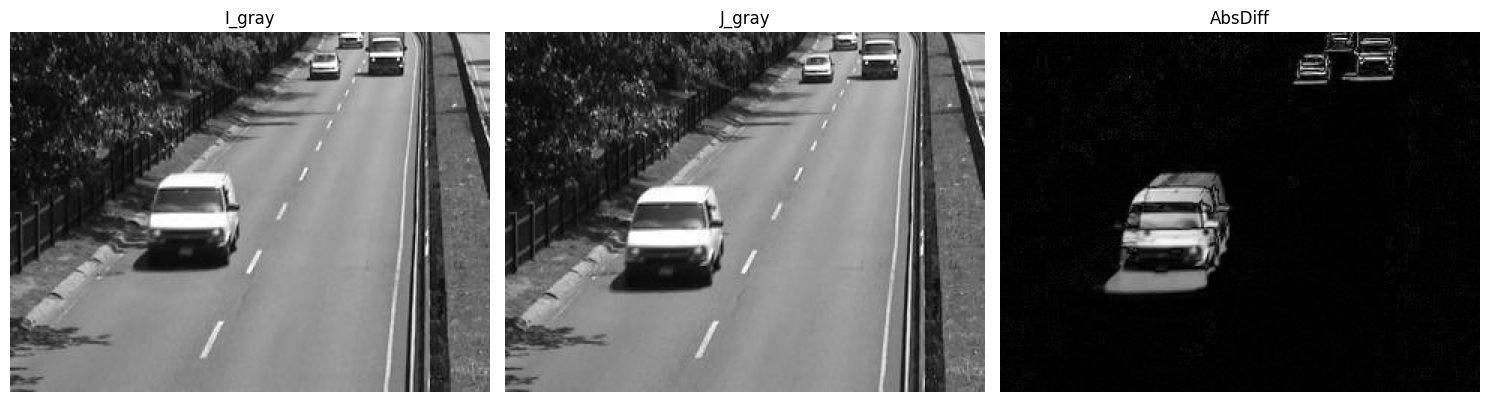

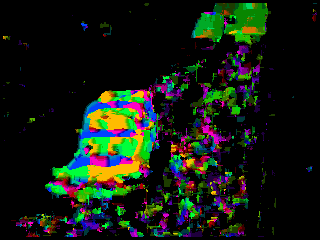

In [11]:
I = images_color['I.jpg']
J = images_color['J.jpg']

I_gray = images_gray['I.jpg']
J_gray = images_gray['J.jpg']

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title('I_gray')
plt.imshow(I_gray, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('J_gray')
plt.imshow(J_gray, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('AbsDiff')
plt.imshow(cv2.absdiff(I_gray, J_gray), cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

W2 = 3
dX = dY = 3

h, w = I_gray.shape

u = np.zeros((h, w), dtype=np.float32)
v = np.zeros((h, w), dtype=np.float32)

for j in range(W2, h - W2):
    for i in range(W2, w - W2):
        IO = np.float32(I_gray[j-W2:j+W2+1, i-W2:i+W2+1])

        min_error = np.inf
        best_dx = 0
        best_dy = 0

        for dy in range(-dY, dY+1):
            for dx in range(-dX, dX+1):
                jj = j + dy
                ii = i + dx

                if W2 <= jj < h - W2 and W2 <= ii < w - W2:
                    JO = np.float32(J_gray[jj-W2:jj+W2+1, ii-W2:ii+W2+1])
                    error = np.sqrt(np.sum((np.square(JO-IO))))

                    if error < min_error:
                        min_error = error
                        best_dx = dx
                        best_dy = dy

        u[j, i] = best_dx
        v[j, i] = best_dy

magnitude, angle = cv2.cartToPolar(u, v)

hsv = np.zeros((h, w, 3), dtype=np.uint8)
hsv[..., 0] = angle * 180 / np.pi / 2
hsv[..., 1] = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)
hsv[..., 2] = 255

hsv[..., 1], hsv[..., 2] = hsv[..., 2].copy(), hsv[..., 1].copy()

flow_rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

cv2_imshow(flow_rgb)

#4.2

Skala: 2


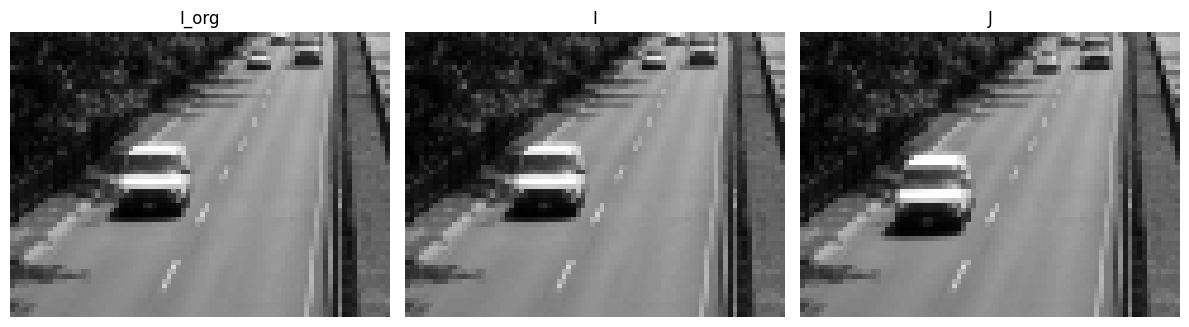

Skala: 1


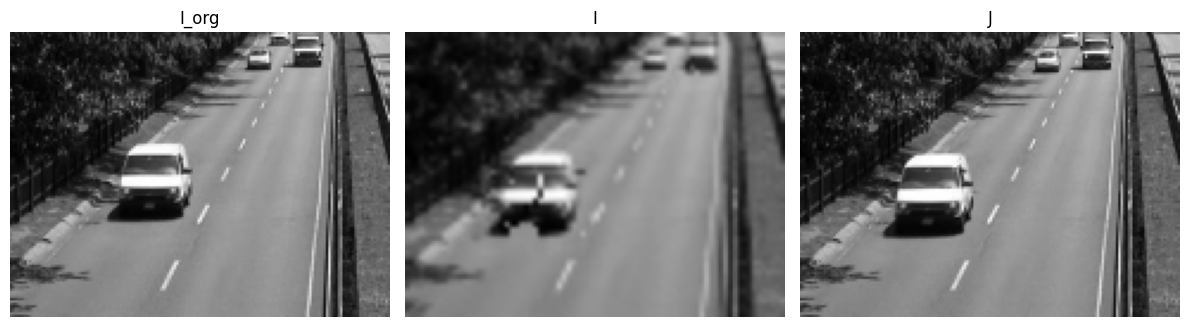

Skala: 0


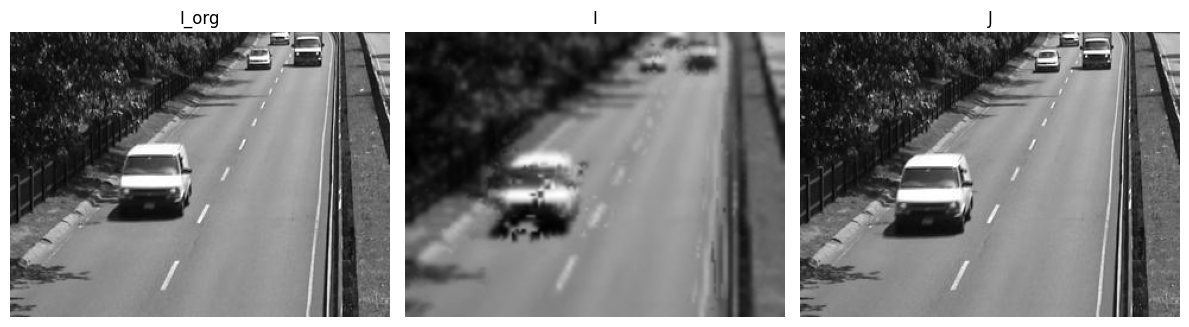

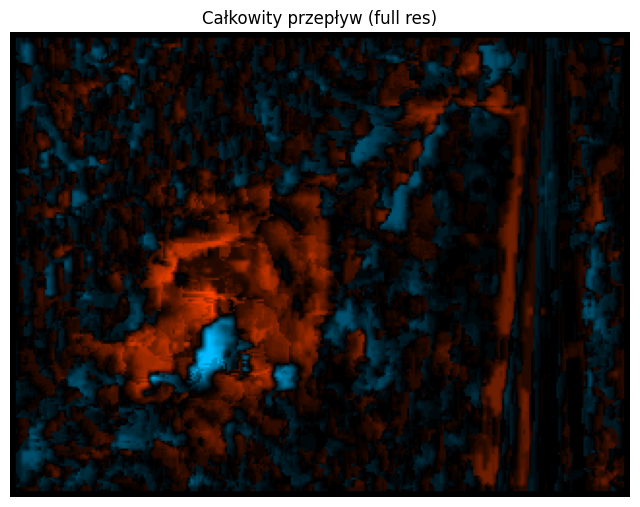

In [13]:
def of(I_org, I, J, W2=3, dY=3, dX=3):
    h, w = I.shape
    u = np.zeros((h, w), dtype=np.float32)
    v = np.zeros((h, w), dtype=np.float32)

    for j in range(W2, h - W2):
        for i in range(W2, w - W2):
            IO = np.float32(I[j-W2:j+W2+1, i-W2:i+W2+1])
            min_error = np.inf
            best_dx = 0
            best_dy = 0
            for dy in range(-dY, dY+1):
                for dx in range(-dX, dX+1):
                    jj = j + dy
                    ii = i + dx
                    if W2 <= jj < h - W2 and W2 <= ii < w - W2:
                        JO = np.float32(J[jj-W2:jj+W2+1, ii-W2:ii+W2+1])
                        error = np.sqrt(np.sum((JO-IO)**2))
                        if error < min_error:
                            min_error = error
                            best_dx = dx
                            best_dy = dy
            u[j, i] = best_dx
            v[j, i] = best_dy

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.title('I_org')
    plt.imshow(I_org, cmap='gray')
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.title('I')
    plt.imshow(I, cmap='gray')
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.title('J')
    plt.imshow(J, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    return u, v

def vis_flow(u, v, YX, name):
    h, w = YX
    magnitude, angle = cv2.cartToPolar(u, v, angleInDegrees=False)
    hsv = np.zeros((h, w, 3), dtype=np.uint8)
    hsv[..., 0] = angle * 90 / np.pi
    hsv[..., 1] = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)
    hsv[..., 2] = 255
    hsv[..., 1], hsv[..., 2] = hsv[..., 2].copy(), hsv[..., 1].copy()
    flow_rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

    plt.figure(figsize=(8,8))
    plt.title(name)
    plt.imshow(flow_rgb)
    plt.axis('off')
    plt.show()

def pyramid(im, max_scale):
    images = [im]
    for k in range(1, max_scale):
        images.append(cv2.resize(images[k-1], (0,0), fx=0.5, fy=0.5))
    return images

I_org = images_color['I.jpg']
J_org = images_color['J.jpg']
I_org = cv2.resize(I_org, (I_org.shape[1], I_org.shape[0]))
J_org = cv2.resize(J_org, (J_org.shape[1], J_org.shape[0]))

I_gray = cv2.cvtColor(I_org, cv2.COLOR_BGR2GRAY)
J_gray = cv2.cvtColor(J_org, cv2.COLOR_BGR2GRAY)

max_scale = 3
IP = pyramid(I_gray, max_scale)
JP = pyramid(J_gray, max_scale)


YX = IP[-1].shape
I = IP[-1]


h_full, w_full = I_gray.shape
u_full = np.zeros((h_full, w_full), dtype=np.float32)
v_full = np.zeros((h_full, w_full), dtype=np.float32)

for scale in range(max_scale-1,-1,-1):
    print(f'Skala: {scale}')
    u, v = of(IP[scale], I, JP[scale], W2=3, dX=3, dY=3)

    u_full = u_full + cv2.resize((2**scale)*u, (0,0), fx=2**scale, fy=2**scale, interpolation=cv2.INTER_LINEAR)
    v_full = v_full + cv2.resize((2**scale)*u, (0,0), fx=2**scale, fy=2**scale, interpolation=cv2.INTER_LINEAR)

    I_new = np.copy(I)

    if scale > 0:
      for j in range(0, YX[0]):
          for i in range(0, YX[1]):
              jj = int(j + v[j, i])
              ii = int(i + u[j, i])
              if 0 <= jj < YX[0] and 0 <= ii < YX[1]:
                  I_new[jj, ii] = I[j, i]
      I = cv2.resize(I_new, (0,0), fx=2, fy=2, interpolation=cv2.INTER_LINEAR)
      YX = I.shape



vis_flow(u_full, v_full, (h_full, w_full), 'Całkowity przepływ (full res)')

